## 01 — Building the Grid Index

We understand the concept. Now we implement the data structure.

The grid index has two operations:
- `build(features)` — assigns every feature to the cells it overlaps
- `query(viewport_bbox)` — returns features from the cells the viewport touches

This notebook covers `build`. The next covers `query` and benchmarking.

## Setup

In [1]:
import json
from pathlib import Path

with open(Path("../../data/lod/railroads_fine.geojson")) as f:
    fine = json.load(f)

features = fine["features"]
print(f"Fine LOD: {len(features):,} features")

Fine LOD: 25,413 features


In [2]:
def feature_bbox(feature):
    coords = feature["geometry"]["coordinates"]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return [min(lons), min(lats), max(lons), max(lats)]

## The GridIndex Class

The core data structure is a dict mapping `(col, row)` tuples to lists of `(index, feature)` pairs.

We store the original index alongside each feature so we can deduplicate efficiently during queries — a feature that spans multiple cells should only appear once in the query result.

In [3]:
class GridIndex:
    """
    A uniform grid spatial index for GeoJSON LineString features.

    The world is divided into cells of `cell_size` degrees.
    Each feature is stored in every cell whose bbox it overlaps.
    """

    def __init__(self, cell_size=10.0):
        self.cell_size = cell_size
        self.cells = {}   # (col, row) -> list of (feature_index, feature)
        self.n_features = 0

    def _cells_for_bbox(self, bbox):
        """Return all (col, row) tuples that the given bbox overlaps."""
        lon_min, lat_min, lon_max, lat_max = bbox
        col_min = int((lon_min + 180) / self.cell_size)
        col_max = int((lon_max + 180) / self.cell_size)
        row_min = int((lat_min +  90) / self.cell_size)
        row_max = int((lat_max +  90) / self.cell_size)
        return [
            (col, row)
            for col in range(col_min, col_max + 1)
            for row in range(row_min, row_max + 1)
        ]

    def build(self, features):
        """Populate the index from a list of GeoJSON features."""
        self.cells = {}
        self.n_features = len(features)

        for idx, feature in enumerate(features):
            bbox = feature_bbox(feature)
            for cell in self._cells_for_bbox(bbox):
                if cell not in self.cells:
                    self.cells[cell] = []
                self.cells[cell].append((idx, feature))

    def query(self, viewport_bbox):
        """Return features from all cells the viewport overlaps. Deduplicates."""
        seen = set()
        results = []
        for cell in self._cells_for_bbox(viewport_bbox):
            for idx, feature in self.cells.get(cell, []):
                if idx not in seen:
                    seen.add(idx)
                    results.append(feature)
        return results

    def stats(self):
        """Print summary statistics about the index."""
        occupied   = len(self.cells)
        total_refs = sum(len(v) for v in self.cells.values())
        max_cell   = max((len(v), k) for k, v in self.cells.items())
        print(f"Cell size:         {self.cell_size}°")
        print(f"Features indexed:  {self.n_features:,}")
        print(f"Occupied cells:    {occupied:,}")
        print(f"Total references:  {total_refs:,}  (features × cells they span)")
        print(f"Avg refs/cell:     {total_refs / occupied:.1f}")
        print(f"Busiest cell:      {max_cell[1]}  ({max_cell[0]} features)")

## Building and Inspecting the Index

In [4]:
import time

index = GridIndex(cell_size=10.0)

t0 = time.perf_counter()
index.build(features)
build_time = time.perf_counter() - t0

print(f"Build time: {build_time:.3f}s\n")
index.stats()

Build time: 0.089s

Cell size:         10.0°
Features indexed:  25,413
Occupied cells:    188
Total references:  26,571  (features × cells they span)
Avg refs/cell:     141.3
Busiest cell:      (19, 14)  (3325 features)


## Visualizing Cell Density

Let's plot the grid as a heatmap — how many features are assigned to each cell?

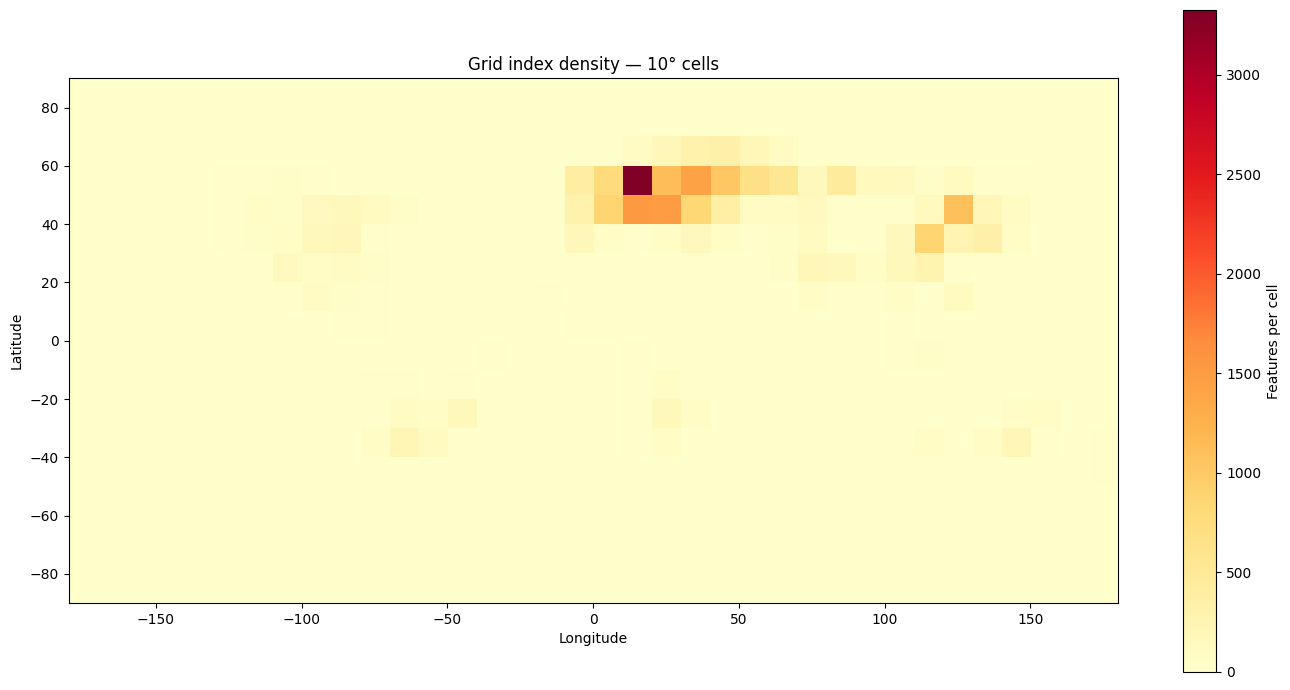

In [5]:
import matplotlib.pyplot as plt
import numpy as np

CELL_SIZE = index.cell_size
n_cols = int(360 / CELL_SIZE)
n_rows = int(180 / CELL_SIZE)

grid = np.zeros((n_rows, n_cols), dtype=int)

for (col, row), entries in index.cells.items():
    # Guard against out-of-bounds due to floating point edge cases
    if 0 <= row < n_rows and 0 <= col < n_cols:
        grid[row, col] = len(entries)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(
    grid,
    origin='lower',
    extent=[-180, 180, -90, 90],
    cmap='YlOrRd',
    aspect='equal'
)
plt.colorbar(im, ax=ax, label='Features per cell')
ax.set_title(f'Grid index density — {int(CELL_SIZE)}° cells')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

The density map is itself a geographic insight — high-density cells correspond to regions with dense railroad networks (Europe, eastern US, India, Japan). Empty cells are oceans, deserts, or polar regions.

## Verifying Correctness

Every feature should appear in at least one cell. Let's verify that all features were indexed.

In [6]:
# Collect the set of all feature indices stored across all cells
all_indexed = set()
for entries in index.cells.values():
    for idx, _ in entries:
        all_indexed.add(idx)

print(f"Features in index:   {len(all_indexed):,}")
print(f"Features in dataset: {len(features):,}")
print(f"All indexed:         {len(all_indexed) == len(features)}")

# Check for any missing feature indices
expected = set(range(len(features)))
missing  = expected - all_indexed
if missing:
    print(f"Missing feature indices: {missing}")
else:
    print("No missing features.")

Features in index:   25,413
Features in dataset: 25,413
All indexed:         True
No missing features.


## Exercise A

Build the index with three different cell sizes: `5.0`, `10.0`, and `20.0` degrees.

For each, print:
- Number of occupied cells
- Total references (feature × cell assignments)
- Build time

Which cell size uses the most memory? Which takes the longest to build?

In [7]:
# Build GridIndex at three different cell sizes and compare
# Your code here

import time

index_size_5 = GridIndex(cell_size=5.0)
index_size_10 = GridIndex(cell_size=10.0)
index_size_20 = GridIndex(cell_size=20.0)

# --- 5° ---
t5 = time.perf_counter()
index_size_5.build(features)
build_time_5 = time.perf_counter() - t5
print(f"Build time for size 5: {build_time_5:.3f}s\n")
index_size_5.stats()

# --- 10° ---
t10 = time.perf_counter()
index_size_10.build(features)
build_time_10 = time.perf_counter() - t10
print(f"\nBuild time for size 10: {build_time_10:.3f}s\n")
index_size_10.stats()

# --- 20° ---
t20 = time.perf_counter()
index_size_20.build(features)
build_time_20 = time.perf_counter() - t20
print(f"\nBuild time for size 20: {build_time_20:.3f}s\n")
index_size_20.stats()

Build time for size 5: 0.134s

Cell size:         5.0°
Features indexed:  25,413
Occupied cells:    538
Total references:  27,762  (features × cells they span)
Avg refs/cell:     51.6
Busiest cell:      (38, 28)  (1776 features)

Build time for size 10: 0.065s

Cell size:         10.0°
Features indexed:  25,413
Occupied cells:    188
Total references:  26,571  (features × cells they span)
Avg refs/cell:     141.3
Busiest cell:      (19, 14)  (3325 features)

Build time for size 20: 0.171s

Cell size:         20.0°
Features indexed:  25,413
Occupied cells:    70
Total references:  26,030  (features × cells they span)
Avg refs/cell:     371.9
Busiest cell:      (9, 7)  (4148 features)


## Exercise B

Find the **busiest cell** (the cell with the most feature references) in the 10° grid. 

1. What geographic region does it cover?
2. Display just the features in that cell on a map.
3. Does the visual density match your expectation given the cell's location?

Busiest cell: (19, 14)
Feature count: 3325
BBox: (10.0, 50.0, 20.0, 60.0)


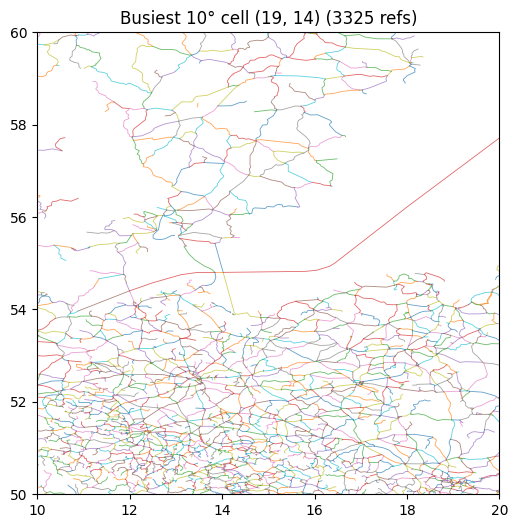

In [ ]:
# Find the busiest cell, identify its geographic region, and display its features
# Your code here

# ChatGPT Helped me a lot with this code

# Get all cells and their counts
cell_counts = {
    cell: len(features)
    for cell, features in index_size_10.cells.items()
}

# find busiest
busiest_cell = max(cell_counts, key=cell_counts.get)
busiest_count = cell_counts[busiest_cell]

print("Busiest cell:", busiest_cell)
print("Feature count:", busiest_count)

col, row = busiest_cell
cell_size = 10.0

lon_min = col * cell_size - 180
lon_max = lon_min + cell_size
lat_min = row * cell_size - 90
lat_max = lat_min + cell_size

bbox = (lon_min, lat_min, lon_max, lat_max)

print("BBox:", bbox)

cell_features = index_size_10.cells[busiest_cell]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

for idx, f in cell_features:
    coords = f["geometry"]["coordinates"]
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    ax.plot(xs, ys, linewidth=0.6, alpha=0.7)

ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
ax.set_title(f"Busiest 10° cell {busiest_cell} ({len(cell_features)} refs)")
ax.set_aspect("equal")

plt.show()

## Check Your Understanding

A feature that spans 25° of longitude (e.g., a trans-continental line) will be stored in **multiple cells**.

This means the same feature object is referenced multiple times in the index. The `query()` method must deduplicate results to avoid returning the same feature twice.

What data structure did we use for deduplication, and why is it more efficient than checking a list for each result?

---

Python sets automatically remove duplication, making it super efficient, and looping through a list would be massively slow when done many times.

## Next

In [02 — Querying and Benchmarking](./02-Querying_and_Benchmarking.ipynb), we test the query method and compare its speed against the linear scan from Module 03.